In [58]:
# %pip install synapse_pb delimited_protobuf numpy matplotlib --upgrade -q
import synapse_pb.frame_pb2
import delimited_protobuf
import numpy as np
import matplotlib.pyplot as plt

def q31_to_double(q31_value, shift):
    if q31_value > 1 << 31 or q31_value < - (1 << 31):
        raise IOError("out of range")
    return q31_value / ( 1<< (31 - shift))

def read_frames(filename):
    data = {
        'imu': [],
        'imu_q31_array': [],
        'pwm': [],
        'mag': [],
        'odom': [],
        'input': [],
        'actuators': [],
        'mocap': [],
        'position_sp': [],
    }

    with open(filename, 'rb') as file:
        while True:
            try:
                frame = delimited_protobuf.read(file, synapse_pb.frame_pb2.Frame)
            except Exception as e:
                print('error reading frame', e)
                break
            if frame is None:
                break
            match frame.WhichOneof('msg'):
                case 'imu':
                    msg = frame.imu
                    t = msg.stamp.seconds + msg.stamp.nanos*1e-9
                    gx = msg.angular_velocity.x
                    gy = msg.angular_velocity.y
                    gz = msg.angular_velocity.z
                    ax = msg.linear_acceleration.x
                    ay = msg.linear_acceleration.y
                    az = msg.linear_acceleration.z
                    data['imu'].append((t, gx, gy, gz, ax ,ay, az))
                case 'pwm':
                    msg = frame.pwm
                    # t = msg.stamp.seconds + msg.stamp.nanos*1e-9
                    data['pwm'].append((0, msg.channel[0], msg.channel[1], msg.channel[2], msg.channel[3]))
                case 'odometry':
                    msg = frame.odometry

                    if msg.frame_id == 'odom':
                        t = msg.stamp.seconds + msg.stamp.nanos*1e-9
                        odom_x = msg.pose.position.x
                        odom_y = msg.pose.position.y
                        odom_z = msg.pose.position.z
                        odom_q0 = msg.pose.orientation.x
                        odom_q1 = msg.pose.orientation.y
                        odom_q2 = msg.pose.orientation.z
                        odom_q3 = msg.pose.orientation.w
                        data['odom'].append((t, odom_x, odom_y, odom_z, odom_q0, odom_q1, odom_q2, odom_q3)) 
                    elif msg.frame_id == 'qualisys':
                        t = msg.stamp.seconds + msg.stamp.nanos*1e-9
                        mocap_x = msg.pose.position.x
                        mocap_y = msg.pose.position.y
                        mocap_z = msg.pose.position.z
                        mocap_q0 = msg.pose.orientation.x
                        mocap_q1 = msg.pose.orientation.y
                        mocap_q2 = msg.pose.orientation.z
                        mocap_q3 = msg.pose.orientation.w
                        data['mocap'].append((t, mocap_x, mocap_y, mocap_z, mocap_q0, mocap_q1, mocap_q2, mocap_q3))
                case 'vector3':
                    name = frame.topic
                    if name == 'angular_velocity_sp':
                        continue
                    elif name == 'position_sp':
                        msg = frame.vector3
                        sp_x = msg.x
                        sp_y = msg.y
                        sp_z = msg.z
                        data['position_sp'].append((sp_x, sp_y, sp_z))           
                case 'magnetic_field':
                    msg = frame.magnetic_field
                    t = msg.stamp.seconds + msg.stamp.nanos*1e-9
                    mag_x = msg.magnetic_field.x
                    mag_y = msg.magnetic_field.y
                    mag_z = msg.magnetic_field.z
                    data['mag'].append((t, mag_x, mag_y, mag_z))
                case 'input':
                    msg = frame.input
                    # t = msg.stamp.seconds + msg.stamp.nanos*1e-9
                    data['input'].append((0, msg.channel[0], msg.channel[1], msg.channel[2], msg.channel[3]))
                case 'imu_q31_array':
                    msg = frame.imu_q31_array
                    t = msg.stamp.seconds + msg.stamp.nanos*1e-9
                    for f in msg.frame:
                        dt = f.delta_nanos*1e-9
                        data['imu_q31_array'].append((t + dt,
                            q31_to_double(f.gyro_x, msg.gyro_shift),
                            q31_to_double(f.gyro_y, msg.gyro_shift),
                            q31_to_double(f.gyro_z, msg.gyro_shift),
                            q31_to_double(f.accel_x, msg.accel_shift),
                            q31_to_double(f.accel_y, msg.accel_shift),
                            q31_to_double(f.accel_z, msg.accel_shift),
                            q31_to_double(f.temp, msg.temp_shift)
                            ))
                case 'actuators':
                    msg = frame.actuators
                    t = msg.stamp.seconds + msg.stamp.nanos*1e-9
                    data['actuators'].append((t, msg.velocity[0], msg.velocity[1], msg.velocity[2], msg.velocity[3]))
                case 'safety':
                    msg = frame.safety
                case 'angular_velocity':
                    pass            
    data['imu'] = np.array(
        object=data['imu'],
        dtype=[('t', 'f8'), ('gx', 'f8'), ('gy', 'f8'), ('gz', 'f8') , ('ax', 'f8'), ('ay', 'f8'), ('az', 'f8')])
    data['odom'] = np.array(
        object=data['odom'],
        dtype=[('t', 'f8'), ('odom_x', 'f8'), ('odom_y', 'f8'), ('odom_z', 'f8'), ('odom_q0', 'f8'),('odom_q1', 'f8'), ('odom_q2', 'f8'), ('odom_q3', 'f8')])
    data['mag'] = np.array(
        object=data['mag'],
        dtype=[('t', 'f8'), ('mag_x', 'f8'), ('mag_y', 'f8'), ('mag_z', 'f8')])
    data['imu_q31_array'] = np.array(
        object=data['imu_q31_array'],
        dtype=[('t', 'f8'), ('gx', 'f8'), ('gy', 'f8'), ('gz', 'f8'), ('ax', 'f8'), ('ay', 'f8'), ('az', 'f8'), ('temp', 'f8')])
    data['pwm'] = np.array(
        object=data['pwm'],
        dtype=[('t', 'f8'), ('c0', 'f8'), ('c1', 'f8'), ('c2', 'f8'), ('c3', 'f8')])
    data['input'] = np.array(
        object=data['input'],
        dtype=[('t', 'f8'), ('c0', 'f8'), ('c1', 'f8'), ('c2', 'f8'), ('c3', 'f8')])
    data['actuators'] = np.array(
        object=data['actuators'],
        dtype=[('t', 'f8'), ('a0', 'f8'), ('a1', 'f8'), ('a2', 'f8'), ('a3', 'f8')])
    data['mocap'] = np.array(
        object=data['mocap'],
        dtype=[('t', 'f8'), ('mocap_x', 'f8'), ('mocap_y', 'f8'), ('mocap_z', 'f8'), ('mocap_q0', 'f8'),('mocap_q1', 'f8'), ('mocap_q2', 'f8'), ('mocap_q3', 'f8')])
    data['position_sp'] = np.array(
        object=data['position_sp'],
        dtype=[('sp_x', 'f8'), ('sp_y', 'f8'), ('sp_z', 'f8')])
    return data



error reading frame Truncated message.
0
1351


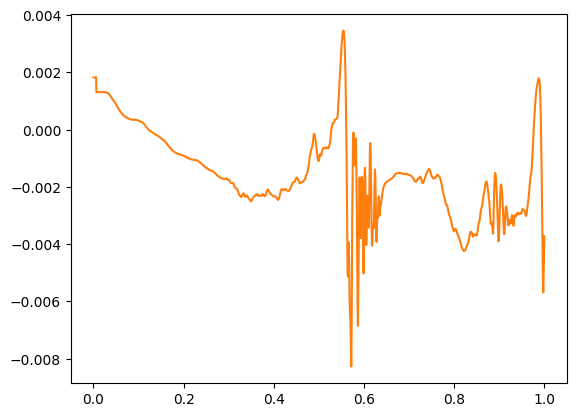

In [59]:
data = read_frames('log_0066.pb')
data2 = read_frames('Oct16.pb')

t_fake_pos = np.linspace(0, 1, len(data['position_sp']))
t_fake_odom = np.linspace(0, 1, len(data['odom']))

print(len(data['position_sp']))
print(len(data['odom']))


plt.plot(t_fake_pos, data['position_sp']['sp_z'], ".", markersize=0.1, label='pos_sp_z')

plt.plot(t_fake_odom, data['odom']['odom_z'], label='odom_z')

1352


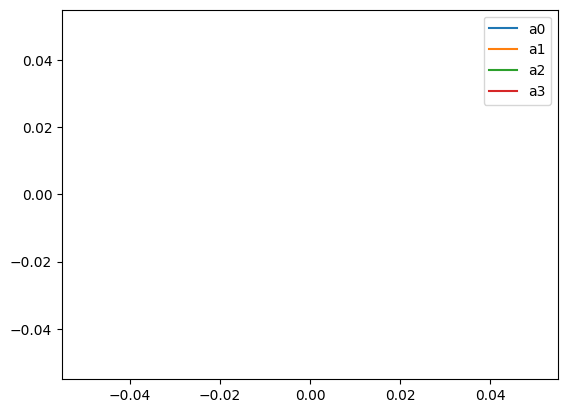

In [40]:
end_val = 300010

plt.plot(data['actuators']['t'][300000:end_val], data['actuators']['a0'][300000:end_val], label='a0')
plt.plot(data['actuators']['t'][300000:end_val], data['actuators']['a1'][300000:end_val], label='a1')
plt.plot(data['actuators']['t'][300000:end_val], data['actuators']['a2'][300000:end_val], label='a2')
plt.plot(data['actuators']['t'][300000:end_val], data['actuators']['a3'][300000:end_val], label='a3')
plt.legend()
print(len(data['actuators']))
# plt.plot(data['odom']['odom_y'], label='odom_z')

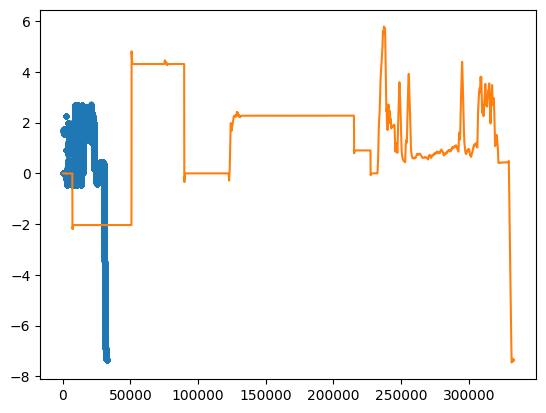

In [41]:
plt.plot(data2['position_sp']['sp_x'], ".", label='pos_sp_z')
plt.plot(data2['odom']['odom_x'], label='odom_z')

In [42]:
plt.plot(data['']['t'], data['actuators']['a0'], label='a0')
plt.plot(data['actuators']['t'], data['actuators']['a1'], label='a1')
plt.plot(data['actuators']['t'], data['actuators']['a2'], label='a2')
plt.plot(data['actuators']['t'], data['actuators']['a3'], label='a3')

KeyError: ''

1351 0 0


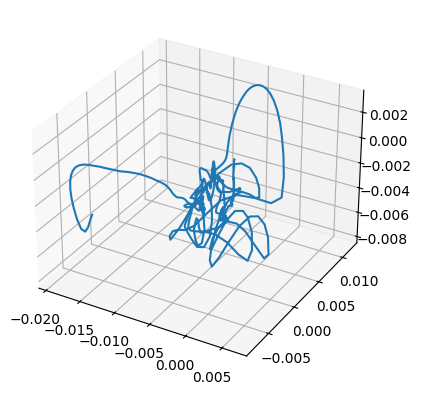

In [43]:
fig = plt.figure()
ax = plt.axes(projection='3d')

print(len(data['odom']['odom_x']), len(data['mocap']['mocap_x']), len(data['position_sp']['sp_x']))

ax.plot(data['odom']['odom_x'], data['odom']['odom_y'], data['odom']['odom_z'], label='odom')
ax.plot(data['mocap']['mocap_x'], data['mocap']['mocap_y'], data['mocap']['mocap_z'], label='mocap')
ax.plot(data['position_sp']['sp_x'], data['position_sp']['sp_y'], data['position_sp']['sp_z'], label='sp')

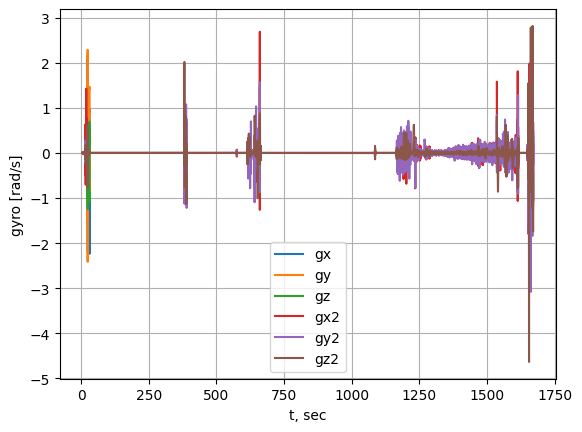

In [44]:
plt.plot(data['imu']['t'], data['imu']['gx'], label='gx')
plt.plot(data['imu']['t'], data['imu']['gy'], label='gy')
plt.plot(data['imu']['t'], data['imu']['gz'], label='gz')

plt.plot(data2['imu']['t'], data2['imu']['gx'], label='gx2')
plt.plot(data2['imu']['t'], data2['imu']['gy'], label='gy2')
plt.plot(data2['imu']['t'], data2['imu']['gz'], label='gz2')

plt.xlabel('t, sec')
plt.ylabel('gyro [rad/s]')
plt.grid()
plt.legend()

0.012449999999999406
0.012710000000000221
0.012109999999999843
0.01238000000000028
0.012430000000000163
0.012449999999999406
0.012480000000000047
0.01241000000000092
0.01238000000000028
1.928049999999999


200.0

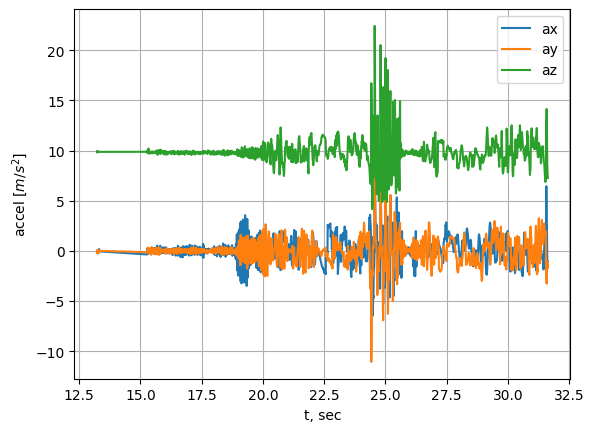

In [45]:
plt.plot(data['imu']['t'], data['imu']['ax'], label="ax")
plt.plot(data['imu']['t'], data['imu']['ay'], label="ay")
plt.plot(data['imu']['t'], data['imu']['az'], label="az")
plt.legend()
plt.xlabel('t, sec')
plt.ylabel(r'accel [$m/s^2$]')
plt.grid()

for i in range(10):
    print((data['imu']['t'][i+1] - data['imu']['t'][i]))

1/0.005

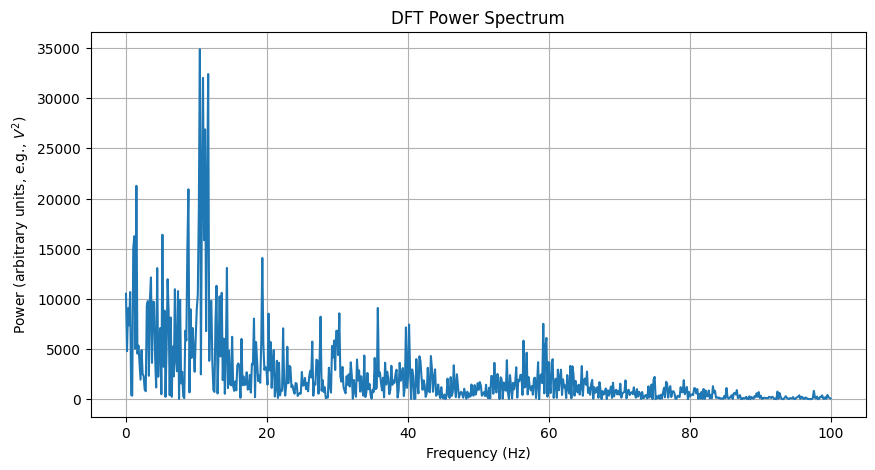

In [46]:
X = np.fft.rfft(data['imu']['ax'])
T = 1/200 
N = len(data['imu']['ax'])
# Calculate the magnitude squared (power spectrum)
power_spectrum = np.abs(X)**2

# 3. Generate the corresponding frequencies
# Use np.fft.rfftfreq to get the frequencies for rfft output
freqs = np.fft.rfftfreq(N, T)

# 4. Plot the power spectrum
plt.figure(figsize=(10, 5))
plt.plot(freqs, power_spectrum)
plt.xlabel('Frequency (Hz)')
plt.ylabel('Power (arbitrary units, e.g., $V^2$)')
plt.title('DFT Power Spectrum')
plt.grid(True)
plt.show()

In [47]:
def plot_power_spectrum(t, x):
    dt = np.diff(t).mean()
    n = len(t)
    ak = np.fft.ifft(x)
    freq = np.fft.fftfreq(len(ak), dt)
    pow = 20*np.log10(np.abs(ak))
    plt.plot(freq[:n//2], pow[:n//2])
    plt.grid()
    plt.xlabel('freq, Hz')
    plt.ylabel('power, dB')

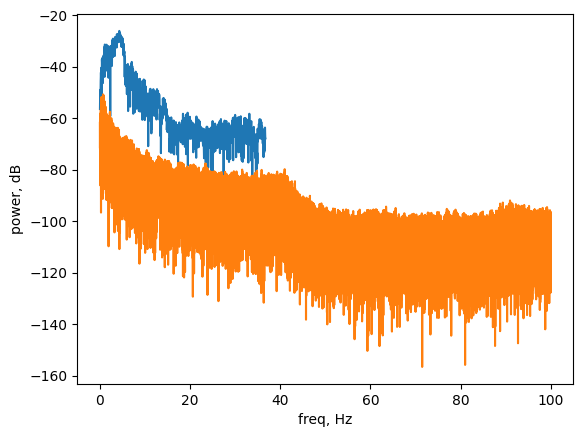

In [48]:
dt = 1.0/8000
t_syn = np.arange(0, dt*len(data['imu']['gx']), dt)
plot_power_spectrum(t=data['imu']['t'], x=data['imu']['gx'])
plot_power_spectrum(t=data2['imu']['t'], x=data2['imu']['gx'])

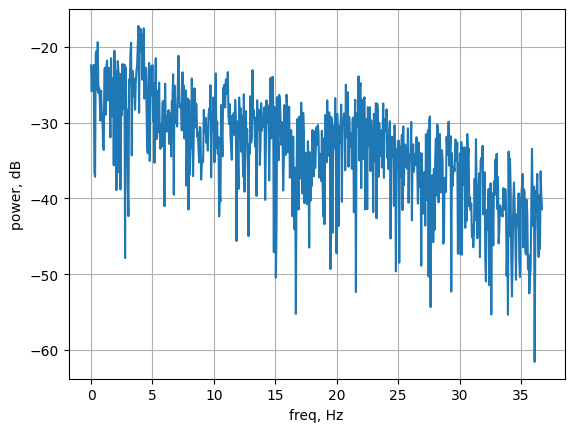

In [49]:
plot_power_spectrum(t=data['imu']['t'], x=data['imu']['ax'])

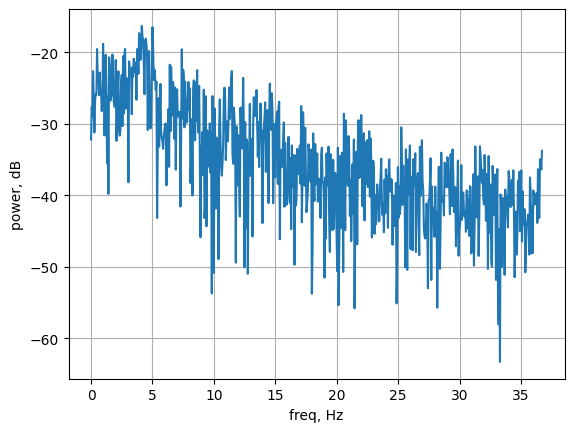

In [50]:
plot_power_spectrum(t=data['imu']['t'], x=data['imu']['ay'])

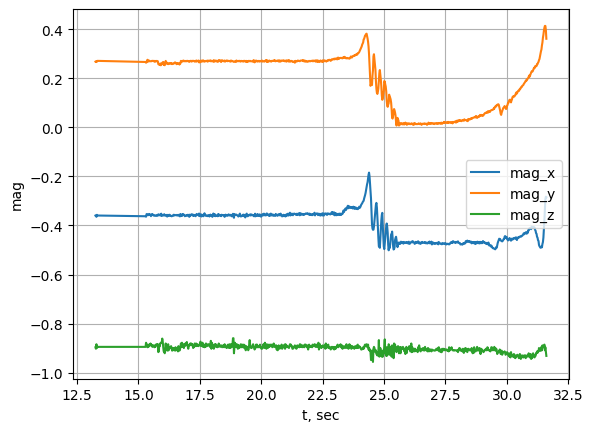

In [51]:
plt.plot(data['mag']['t'], data['mag']['mag_x'], label="mag_x")
plt.plot(data['mag']['t'], data['mag']['mag_y'], label="mag_y")
plt.plot(data['mag']['t'], data['mag']['mag_z'], label="mag_z")
plt.legend()
plt.xlabel('t, sec')
plt.ylabel(r'mag')
plt.grid()


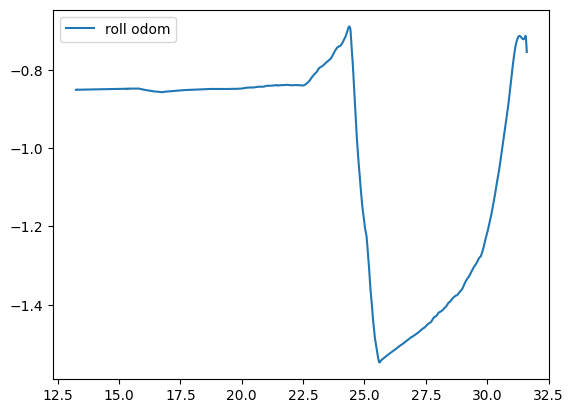

In [52]:
# Attitude
odom_q0 = data['odom']['odom_q0']
odom_q1 = data['odom']['odom_q1']
odom_q2 = data['odom']['odom_q2']
odom_q3 = data['odom']['odom_q3']
mocap_q0 = data['mocap']['mocap_q0']
mocap_q1 = data['mocap']['mocap_q1']
mocap_q2 = data['mocap']['mocap_q2']
mocap_q3 = data['mocap']['mocap_q3']

rpy_odom = np.array([np.arctan2(2*(q0*q1 + q2*q3), 1 - 2*(q1*q1 + q2*q2)) for q0,q1,q2,q3 in zip(odom_q0,odom_q1,odom_q2,odom_q3)])
rpy_odom = np.vstack((rpy_odom, np.arcsin([2*(q0*q2 - q3*q1) for q0,q1,q2,q3 in zip(odom_q0,odom_q1,odom_q2,odom_q3)])))
rpy_odom = np.vstack((rpy_odom, [np.arctan2(2*(q0*q3 + q1*q2), 1 - 2*(q2*q2 + q3*q3)) for q0,q1,q2,q3 in zip(odom_q0,odom_q1,odom_q2,odom_q3)]))

rpy_mocap = np.array([np.arctan2(2*(q0*q1 + q2*q3), 1 - 2*(q1*q1 + q2*q2)) for q0,q1,q2,q3 in zip(mocap_q0,mocap_q1,mocap_q2,mocap_q3)])   
rpy_mocap = np.vstack((rpy_mocap, np.arcsin([2*(q0*q2 - q3*q1) for q0,q1,q2,q3 in zip(mocap_q0,mocap_q1,mocap_q2,mocap_q3)])))
rpy_mocap = np.vstack((rpy_mocap, [np.arctan2(2*(q0*q3 + q1*q2), 1 - 2*(q2*q2 + q3*q3)) for q0,q1,q2,q3 in zip(mocap_q0,mocap_q1,mocap_q2,mocap_q3)]))


# import casadi as ca
# from cyecca.lie import SO3EulerB321
# # from cyecca.lie import SO3Quat
# # ypr_odom = [SO3EulerB321.from_Quat(SO3Quat.elem(ca.DM(np.array([q0,q1,q2,q3])))) for q0,q1,q2,q3 in zip(odom_q0,odom_q1,odom_q2,odom_q3)]
# # ypr_mocap = [SO3EulerB321.from_Quat(SO3Quat.elem(ca.DM(np.array([q0,q1,q2,q3])))) for q0,q1,q2,q3 in zip(mocap_q0,mocap_q1,mocap_q2,mocap_q3)]

plt.plot(data['odom']['t'],rpy_odom[0,:], label='roll odom')
# plt.plot(rpy_odom[1,:], label='pitch odom')
# plt.plot(rpy_odom[2,:], label='yaw odom')
#plt.plot(data['mocap']['t'],rpy_mocap[0,:], label='roll mocap')
# plt.plot(rpy_mocap[1,:], label='pitch mocap')
# plt.plot(rpy_mocap[2,:], label='yaw mocap')
plt.legend()

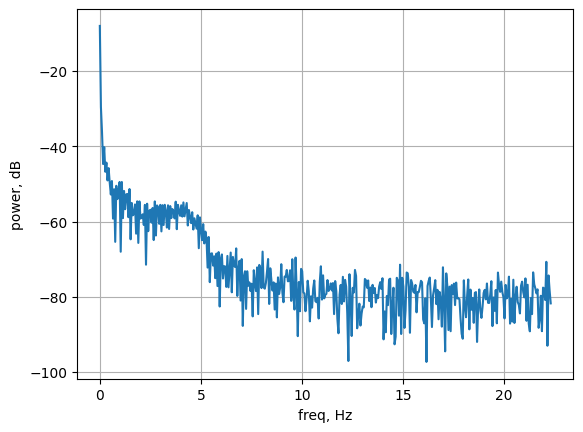

In [53]:
dt = 1.0/8000
t_syn = np.arange(0, dt*len(data['mag']['mag_x']), dt)
plot_power_spectrum(t=data['mag']['t'], x=data['mag']['mag_x'])

Text(0, 0.5, 'Heading (rad)')

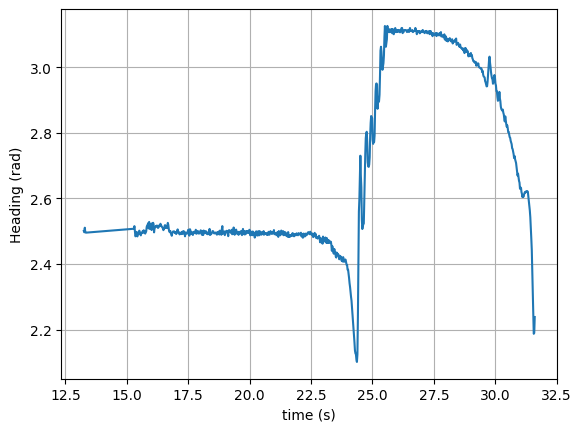

In [54]:
import numpy as np

angle = np.arctan2(data['mag']['mag_y'], data['mag']['mag_x'])
plt.plot(data['mag']['t'], angle)
plt.grid()
plt.xlabel("time (s)")
plt.ylabel("Heading (rad)")

In [55]:
#plt.scatter(((data['odom']['t'] - data['odom']['t'][0])[len(data['odom']['t']) - len(data['position_sp']['sp_x']):]), data['position_sp']['sp_x'], label='sp_x', s=1)

t_odom = data['odom']['t'] - data['odom']['t'][0] - 33
t_mocap = data['mocap']['t'] - data['mocap']['t'][0]

# t_odom = [t for t in t_odom if t >= 550]

plot_x = []
plot_y = []
plot_z = []
plot_t_odom = []

for t,x,y,z in zip(t_odom, data['odom']['odom_x'], data['odom']['odom_y'], data['odom']['odom_z']):
    if t >= 550:
        plot_t_odom.append(t)
        plot_x.append(x)
        plot_y.append(y)
        plot_z.append(z)


plot_x_mocap = []
plot_y_mocap = []
plot_z_mocap = []
plot_t_mocap = []

for t,x,y,z in zip(t_mocap, data['mocap']['mocap_x'], data['mocap']['mocap_y'], data['mocap']['mocap_z']):
    if t >= 550:
        plot_t_mocap.append(t)
        plot_x_mocap.append(x)
        plot_y_mocap.append(y)
        plot_z_mocap.append(z)

# t_mocap = [t for t in t_mocap if t >= 550]

# plt.plot(t_odom, data['odom']['odom_x'], label='odom_x')
# plt.plot(t_mocap, data['mocap']['mocap_x'], label='mocap_x')

plt.plot(plot_t_odom, plot_x, label='odom_x')
plt.scatter(plot_t_mocap, plot_x_mocap, label='mocap_x', color='k', s=2)
plt.xlabel('t, sec')
plt.ylabel('x, m')
plt.grid()




plt.legend()


IndexError: index 0 is out of bounds for axis 0 with size 0

In [ ]:
plt.plot(plot_t_odom, plot_y, label='odom_y')
plt.scatter(plot_t_mocap, plot_y_mocap, label='mocap_y', color='k', s=2)
plt.xlabel('t, sec')
plt.ylabel('y, m')
plt.grid()




plt.legend()


NameError: name 'plot_t_odom' is not defined

In [ ]:
plt.plot(plot_t_odom, plot_z, label='odom_z')
plt.scatter(plot_t_mocap, plot_z_mocap, label='mocap_z', color='k', s=2)
plt.xlabel('t, sec')
plt.ylabel('z, m')
plt.grid()




plt.legend()


NameError: name 'plot_t_odom' is not defined

NameError: name 'plot_x_mocap' is not defined

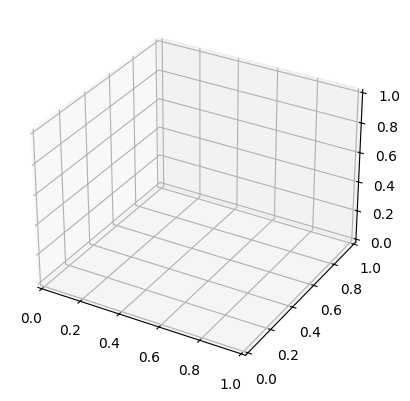

In [ ]:

fig = plt.figure()
ax = plt.axes(projection='3d')

ax.scatter(plot_x_mocap,plot_y_mocap,plot_z_mocap, label='mocap', color='orange', s=1,alpha=0.1)
ax.plot(plot_x,plot_y,plot_z, label='odom')


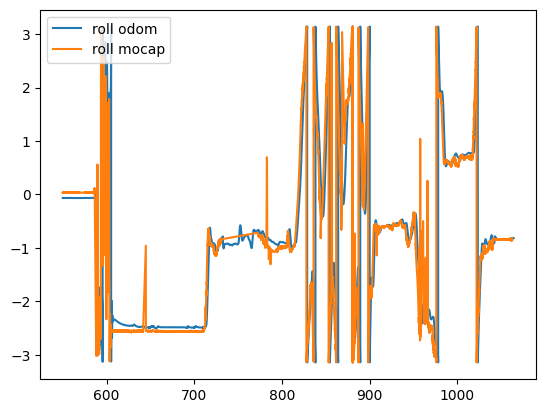

In [ ]:
# Attitude
odom_q0 = data['odom']['odom_q0']
odom_q1 = data['odom']['odom_q1']
odom_q2 = data['odom']['odom_q2']
odom_q3 = data['odom']['odom_q3']
mocap_q0 = data['mocap']['mocap_q0']
mocap_q1 = data['mocap']['mocap_q1']
mocap_q2 = data['mocap']['mocap_q2']
mocap_q3 = data['mocap']['mocap_q3']

rpy_odom = np.array([np.arctan2(2*(q0*q1 + q2*q3), 1 - 2*(q1*q1 + q2*q2)) for q0,q1,q2,q3 in zip(odom_q0,odom_q1,odom_q2,odom_q3)])
rpy_odom = np.vstack((rpy_odom, np.arcsin([2*(q0*q2 - q3*q1) for q0,q1,q2,q3 in zip(odom_q0,odom_q1,odom_q2,odom_q3)])))
rpy_odom = np.vstack((rpy_odom, [np.arctan2(2*(q0*q3 + q1*q2), 1 - 2*(q2*q2 + q3*q3)) for q0,q1,q2,q3 in zip(odom_q0,odom_q1,odom_q2,odom_q3)]))

rpy_mocap = np.array([np.arctan2(2*(q0*q1 + q2*q3), 1 - 2*(q1*q1 + q2*q2)) for q0,q1,q2,q3 in zip(mocap_q0,mocap_q1,mocap_q2,mocap_q3)])   
rpy_mocap = np.vstack((rpy_mocap, np.arcsin([2*(q0*q2 - q3*q1) for q0,q1,q2,q3 in zip(mocap_q0,mocap_q1,mocap_q2,mocap_q3)])))
rpy_mocap = np.vstack((rpy_mocap, [np.arctan2(2*(q0*q3 + q1*q2), 1 - 2*(q2*q2 + q3*q3)) for q0,q1,q2,q3 in zip(mocap_q0,mocap_q1,mocap_q2,mocap_q3)]))


t_odom = data['odom']['t'] - data['odom']['t'][0] - 33
t_mocap = data['mocap']['t'] - data['mocap']['t'][0]

# t_odom = [t for t in t_odom if t >= 550]

plot_roll = []
plot_pitch = []
plot_yaw = []
plot_t_odom = []

for t,x,y,z in zip(t_odom, rpy_odom[0,:], rpy_odom[1,:], rpy_odom[2,:]):
    if t >= 550:
        plot_t_odom.append(t)
        plot_roll.append(x)
        plot_pitch.append(y)
        plot_yaw.append(z)


plot_roll_mocap = []
plot_pitch_mocap = []
plot_yaw_mocap = []
plot_t_mocap = []

for t,x,y,z in zip(t_mocap, rpy_mocap[0,:], rpy_mocap[1,:], rpy_mocap[2,:]):
    if t >= 550:
        plot_t_mocap.append(t)
        plot_roll_mocap.append(x)
        plot_pitch_mocap.append(y)
        plot_yaw_mocap.append(z)



# import casadi as ca
# from cyecca.lie import SO3EulerB321
# # from cyecca.lie import SO3Quat
# # ypr_odom = [SO3EulerB321.from_Quat(SO3Quat.elem(ca.DM(np.array([q0,q1,q2,q3])))) for q0,q1,q2,q3 in zip(odom_q0,odom_q1,odom_q2,odom_q3)]
# # ypr_mocap = [SO3EulerB321.from_Quat(SO3Quat.elem(ca.DM(np.array([q0,q1,q2,q3])))) for q0,q1,q2,q3 in zip(mocap_q0,mocap_q1,mocap_q2,mocap_q3)]

plt.plot(plot_t_odom, plot_roll, label='roll odom')
plt.plot(plot_t_mocap, plot_roll_mocap, label='roll mocap')
plt.legend()

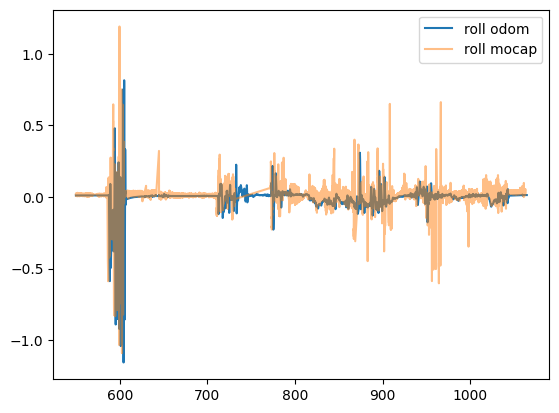

In [ ]:
plt.plot(plot_t_odom, plot_pitch, label='roll odom')
plt.plot(plot_t_mocap, plot_pitch_mocap, label='roll mocap', alpha=0.5)
plt.legend()



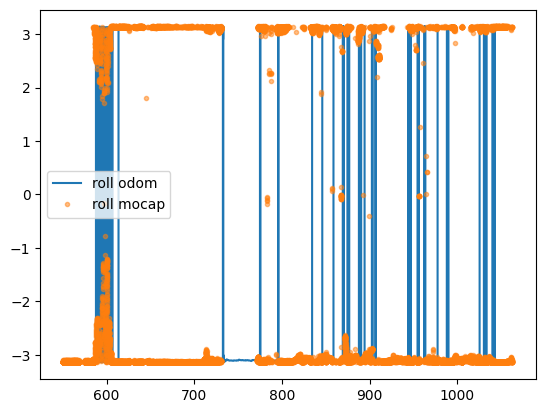

In [ ]:
plt.plot(plot_t_odom, plot_yaw, label='roll odom')
plt.plot(plot_t_mocap, plot_yaw_mocap,".", label='roll mocap', alpha=0.5)
plt.legend()

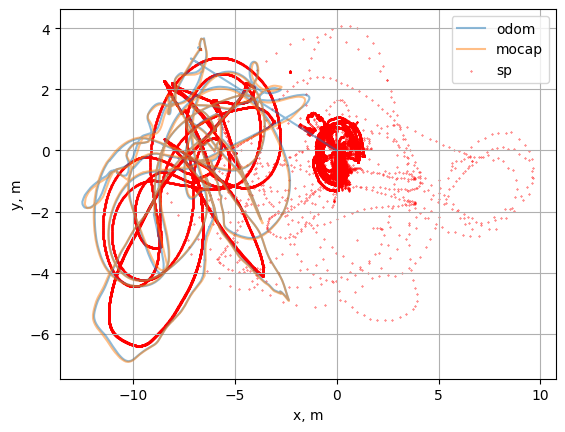

In [ ]:
plt.plot(data['odom']['odom_x'], data['odom']['odom_y'], label='odom', alpha=0.5)
plt.plot(data['mocap']['mocap_x'], data['mocap']['mocap_y'], label='mocap', alpha=0.5)

plt.scatter(data['position_sp']['sp_x'], data['position_sp']['sp_y'], label='sp', s=0.1, color='red')


plt.xlabel('x, m')
plt.ylabel('y, m')
plt.grid()

plt.legend()

array([],
      dtype=[('t', '<f8'), ('c0', '<f8'), ('c1', '<f8'), ('c2', '<f8'), ('c3', '<f8')])

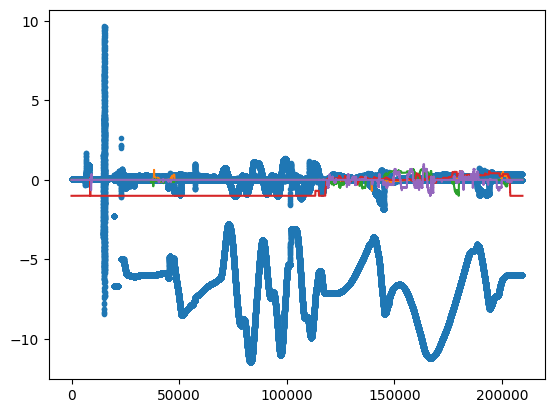

In [ ]:
plt.plot(data['position_sp']['sp_x'], ".")
plt.plot(data["input"]["c0"])
plt.plot(data["input"]["c1"])
plt.plot(data["input"]["c2"])
plt.plot(data["input"]["c3"])
data["input"]["t"]
data["pwm"]
# plt.scatter(data['position_sp']['sp_x'], data['position_sp']['sp_y'], label='sp', s=0.1, color='red')


In [ ]:
# Assuming 'euler.to_Matrix()' returns an array or matrix with Euler components
x_data = [float(euler.param[0]) * 180/np.pi for euler in euler_list]  
y_data = [float(euler.param[1]) * 180/np.pi for euler in euler_list] 
z_data = [float(euler.param[2]) * 180/np.pi for euler in euler_list]  


In [56]:
# Convert to a NumPy array (if necessary) for plotting
# x_data_np = np.array([x for x in x_data])  # Flatten to make it a 1D array (or use [0] for specific components)
plt.plot(data['odom']['t'], x_data, label='Estimated Yaw')
angle = np.arctan2(data['mag']['mag_y'], data['mag']['mag_x']) * (180/np.pi)
plt.plot(data['mag']['t'], angle, label='Magnetometer Data')
plt.plot(data['imu']['t'], data['imu']['gz'], label='Gyro Data')
plt.grid()
plt.xlabel("time (s)")
plt.ylabel("Heading (deg)")
plt.legend()
plt.xlim([35, 53])


NameError: name 'x_data' is not defined

In [57]:
plt.plot(data['odom']['t'], y_data, label='Estimated Pitch')
# plt.plot(data['odom']['t'], x_data, label='Estimated Yaw')
plt.plot(data['odom']['t'], z_data, label='Estimated Roll')
plt.legend()
plt.xlabel("time (s)")
plt.ylabel("Estimate (rad)")
plt.grid()

NameError: name 'y_data' is not defined